In [81]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Download necessary NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [83]:
# 1. Dataset_Load & EDA
df = pd.read_csv('online_reviews_sentiment.csv', parse_dates=['date'])
# Basic EDA
print(df.info())
print(f"Duplicates: {df.duplicated().sum()}")
print(df['sentiment'].value_counts())
print(df['source'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    1000 non-null   int64         
 1   review_text  1000 non-null   object        
 2   product      1000 non-null   object        
 3   sentiment    1000 non-null   object        
 4   source       1000 non-null   object        
 5   date         1000 non-null   datetime64[ns]
 6   rating       1000 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 54.8+ KB
None
Duplicates: 0
sentiment
positive    400
negative    340
neutral     260
Name: count, dtype: int64
source
Flipkart    600
Twitter     400
Name: count, dtype: int64


In [85]:
# 2. Custom Data Cleaning and Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def custom_clean_text(text):
    """
    Custom cleaning: Lowers text, removes URLs/mentions, removes punctuation, 
    strips numbers, and applies lemmatization to group word variants.
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text) # NEW: Remove standalone numbers
    
    tokens = word_tokenize(text)
    # NEW: Apply lemmatization (e.g., 'running' -> 'run') alongside stopword removal
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalpha() and t not in stop_words]
    
    return ' '.join(tokens)

df['clean_text'] = df['review_text'].apply(custom_clean_text)

# Custom Feature Extraction Justification:
tfidf = TfidfVectorizer(min_df=3, max_df=0.85, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

In [55]:
# 3. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [89]:
# 4. Model Selection & Justification
"""Logistic Regression (Balanced): A fast, interpretable linear baseline. Adding class_weight='balanced' ensures it handles any slight class imbalances.
   Random Forest: A non-linear ensemble method that handles sparse TF-IDF matrices well and resists overfitting via bagging.
   Gradient Boosting: A sequential ensemble method that builds trees to correct previous errors, often achieving higher accuracy on complex linguistic patterns than standalone trees."""

models = {
    "Logistic Regression (Balanced)": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})

                            Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression (Balanced)       1.0        1.0     1.0       1.0
1                   Random Forest       1.0        1.0     1.0       1.0
2               Gradient Boosting       1.0        1.0     1.0       1.0
Best model: Logistic Regression (Balanced)



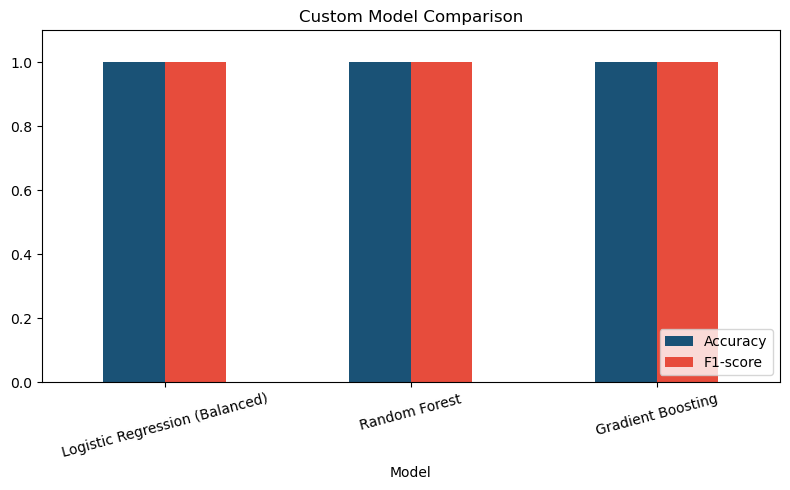

In [113]:
# 5. Evaluation and Model Comparison
results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
print(results_df)

# Visualization: Comparison Chart
fig, ax = plt.subplots(figsize=(8,5))
results_df.set_index("Model")[["Accuracy", "F1-score"]].plot.bar(ax=ax, color=['#1A5276', '#E74C3C'])
plt.title("Custom Model Comparison")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('custom_model_comparison.png')

print(f"Best model: {best_name}\n")

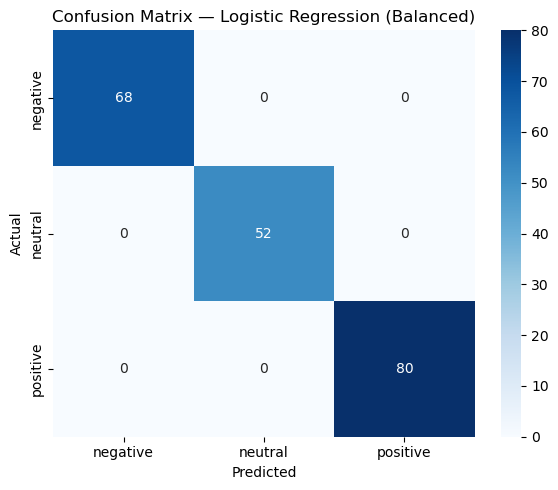

In [101]:
# Visualization: Confusion Matrix for Best Model
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds, labels=best_model.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig('custom_confusion_matrix.png')

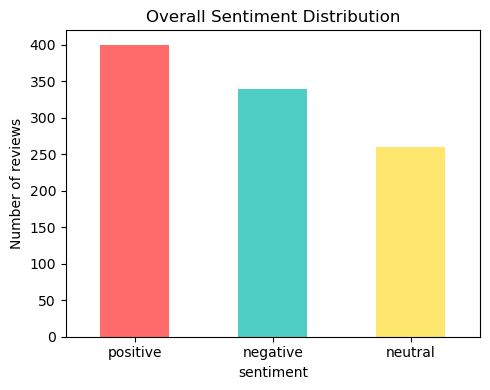

In [93]:
# Visualizing setiment trend
sent_counts = df['sentiment'].value_counts()
plt.figure(figsize=(5,4))
sent_counts.plot.bar(color=['#FF6B6B', '#4ECDC4', '#FFE66D'])
plt.title("Overall Sentiment Distribution")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

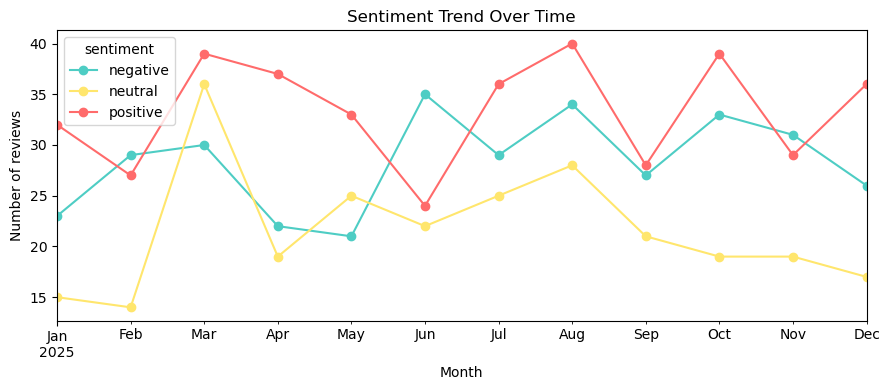

In [95]:
# Sent ovr time
monthly = df.set_index('date').groupby([pd.Grouper(freq='ME'), 'sentiment']).size().unstack(fill_value=0)
monthly.plot(figsize=(9,4), marker='o', color=['#4ECDC4','#FFE66D','#FF6B6B'])
plt.title("Sentiment Trend Over Time")
plt.ylabel("Number of reviews")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

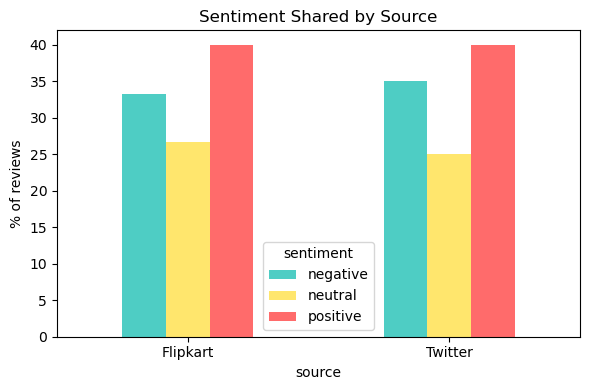

In [119]:
#source_given_overview
source_sentiment = pd.crosstab(df['source'], df['sentiment'], normalize='index') * 100
source_sentiment.plot.bar(figsize=(6,4), color=['#4ECDC4','#FFE66D','#FF6B6B'])
plt.title("Sentiment Shared by Source")
plt.ylabel("% of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()